<a href="https://colab.research.google.com/github/Kamali1265/ML-Ops-Tasks/blob/main/DAY-6/naive_bayes_traffic_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h2 style='color:purple' align='center'>Naive Bayes</h2>

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("traffic_naive_bayes_dataset.csv")
df.head()

,vehicle_count,avg_speed,signal_wait_time,peak_hour,congestion_level
0,177,78,33,1,Medium
1,214,61,11,0,Medium
2,250,68,14,0,High
3,227,36,55,0,High
4,51,28,57,0,High


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   vehicle_count     30 non-null     int64 
 1   avg_speed         30 non-null     int64 
 2   signal_wait_time  30 non-null     int64 
 3   peak_hour         30 non-null     int64 
 4   congestion_level  30 non-null     object
dtypes: int64(4), object(1)
memory usage: 1.3+ KB


In [4]:
df['congestion_level'] = df['congestion_level'].map({
    'Low':0,
    'Medium':1,
    'High':2
})

df.head()

,vehicle_count,avg_speed,signal_wait_time,peak_hour,congestion_level
0,177,78,33,1,1
1,214,61,11,0,1
2,250,68,14,0,2
3,227,36,55,0,2
4,51,28,57,0,2


In [5]:
X = df.drop('congestion_level', axis='columns')
y = df['congestion_level']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()

model.fit(X_train, y_train)

GaussianNB()

In [8]:
model.score(X_test, y_test)

0.3333333333333333

In [9]:
model.predict([[250, 30, 45, 1]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


array([2])

In [10]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

cm

array([[0, 0, 3],
       [0, 1, 0],
       [0, 1, 1]])

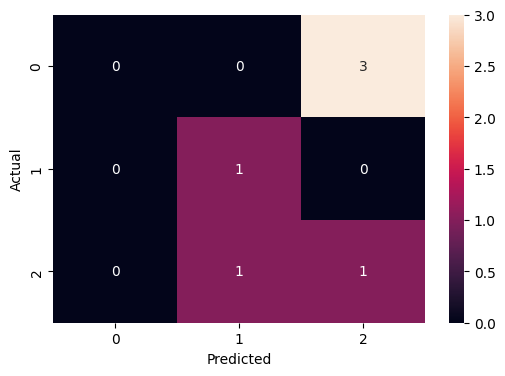

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()